# 📘 Módulo 5 — Teste de Hipóteses
## Livro Didático Aplicado (Híbrido)

- 🔵 **Conteúdo oficial do módulo 5 (IBM)**
- 🟣 **Conteúdo expandido (Livro Didático)**
- 🟠 **Conteúdo avançado (Opcional, matemático)** 

Este notebook segue o mesmo padrão dos módulos anteriores:

- clareza didática,
- profundidade conceitual,
- rigor matemático,
- explicações intuitivas,
- aplicações práticas,
- demonstrações opcionais em `<details>`.

Você pode:
- seguir só o que é 🔵 (curso),
- explorar o 🟣 (livro didático),
- abrir o 🟠 (avançado) quando quiser ir mais fundo.

<a id="indice"></a>
# 📚 Índice

0. [Setup — bibliotecas e dados](#setup)
1. [Introdução ao Teste de Hipóteses](#intro)
2. [Teste Z vs Teste T](#zvt)
3. [Caudas e regiões de rejeição](#caudas)
4. [Teste T para duas amostras independentes](#t2samples)
5. [ANOVA — Análise de Variância](#anova)
6. [Testes de correlação (Qui‑quadrado e Pearson)](#correlacao)
7. [Aplicações com teaching ratings](#aplicacoes)
8. [Exercícios guiados](#exercicios)
9. [Apêndice matemático avançado](#apendice)
10. [Teste A/B — Aplicação Moderna do Teste T](#ab)
11. [Posts](#posts)

<a id="setup"></a>
# 0. Setup — bibliotecas e dados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t, levene, f_oneway, chi2_contingency, pearsonr, ttest_ind

plt.style.use("seaborn-v0_8-whitegrid")
ratings_df = pd.read_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv")
ratings_df.head()

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1


🔵 **Dataset teaching ratings (IBM)**

O módulo 5 continua usando o mesmo dataset dos módulos anteriores.
Ele contém:
- avaliações de ensino (`eval`),
- características dos instrutores,
- número de alunos,
- variáveis categóricas e numéricas.

Este dataset será usado para:
- testes t,
- testes z,
- ANOVA,
- testes de correlação,
- testes qui‑quadrado.

In [ ]:
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv"
ratings_df = pd.read_csv(ratings_url)
ratings_df.to_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv", index=False)
ratings_df.head()

In [ ]:
# Carregamento local
ratings_df = pd.read_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv")
ratings_df.head()

## 🔵 Conexão com o curso IBM

O módulo 5 apresenta:

1. **Teste Z vs Teste T**  
   - quando usar cada um  
   - desvio padrão populacional conhecido vs desconhecido  
   - quatro cenários clássicos  

2. **Caudas e regiões de rejeição**  
   - valores críticos (1.96, 1.64)  
   - testes bilaterais e unilaterais  

3. **Variâncias iguais x desiguais**  
   - teste de Levene  
   - variância combinada  
   - regra prática da razão < 1.5  

4. **ANOVA (One-way ANOVA)**  
   - comparação de 3+ médias  
   - distribuição F  

5. **Testes de correlação**  
   - Qui‑quadrado para variáveis categóricas  
   - Pearson para variáveis contínuas  

Este notebook segue exatamente essa ordem — com explicações ampliadas, rigor matemático e visualizações adicionais.

## 🟣 Antes de avançar

A partir daqui, entraremos no conteúdo central do módulo:

- hipóteses nula e alternativa,  
- testes z e t,  
- regiões críticas,  
- variâncias iguais vs desiguais,  
- ANOVA,  
- correlação,  
- qui‑quadrado.

Cada seção terá:

- definição clara,  
- explicação intuitiva,  
- interpretação geométrica,  
- exemplos numéricos,  
- gráficos,  
- e aprofundamentos opcionais em `<details>`.

Vamos começar pela base: **o que é um teste de hipótese**.

<br>

---

<a id="intro"></a>
[↑ Índice](#indice)
# 1. Introdução ao Teste de Hipóteses

🔵 **Conteúdo oficial do módulo 5 (IBM)**

O curso inicia o módulo 5 explicando que testes de hipóteses são usados para:

- comparar médias,
- comparar proporções,
- comparar variâncias,
- verificar associações entre variáveis,
- avaliar correlação.

O foco inicial é:
- **comparação de médias** usando testes Z e T.

Vamos construir a base conceitual antes de entrar nos testes específicos.

## 1.1 O que é um teste de hipótese?

Um **teste de hipótese** é um procedimento estatístico para avaliar uma afirmação
sobre um parâmetro populacional.

**Os elementos fundamentais são:**

-  🔹 **Hipótese nula (H₀)**
    - A afirmação que assumimos como verdadeira até que haja evidência suficiente contra ela.

| Exemplo: | $ \rightarrow \qquad  H_0: \mu_1 = \mu_2 $ |
|-|-|

- 🔹 **Hipótese alternativa (Hₐ)**
    - A afirmação que queremos investigar.

| Exemplo: | $ \rightarrow \qquad H_a: \mu_1 \ne \mu_2 $ |
|-|-|

- 🔹 **Estatística de teste**
    - Uma medida calculada a partir dos dados que indica quão distante estamos do valor esperado sob $H₀$.

- 🔹 **Valor‑p**
    - Probabilidade de observarmos um valor tão extremo quanto o observado **assumindo que $H₀$ é verdadeira**.

- 🔹 **Nível de significância $(α) \rightarrow margem \ de \ erro$**
    - Probabilidade máxima de rejeitar $H₀$ quando ela é verdadeira $(erro \ tipo \ I)$.

    - Valores típicos para $(α) \rightarrow margem \ de \ erro$:
        - 0.05  
        - 0.01  
        - 0.10  

## 1.2 Estrutura geral de um teste de hipótese

Todo teste segue os mesmos passos:

1. **Declare H₀ e Hₐ**
2. **Escolha o teste apropriado** (Z, T, ANOVA, Qui‑quadrado…)
3. **Calcule a estatística de teste**
4. **Calcule o valor‑p**
5. **Compare com α**
6. **Decida**: rejeitar ou não rejeitar H₀

O módulo 5 da IBM foca principalmente nos testes:

- **Z‑test**  
- **T‑test**  
- **ANOVA**  
- **Qui‑quadrado**  
- **Correlação de Pearson**

## 1.3 Tipos de testes de hipótese

Existem três formas principais de hipóteses alternativas:

| Hipóteses  | Formas |
|-|-|
| 🔹 Teste bilateral (two‑tailed) | <br> $ \rightarrow \qquad H_a: \mu_1 \ne \mu_2 $ <br><br> |
| 🔹 Teste unilateral à direita (right‑tailed) | <br> $ \rightarrow \qquad H_a: \mu_1 > \mu_2 $ <br><br> |
| 🔹 Teste unilateral à esquerda (left‑tailed) | <br> $ \rightarrow \qquad H_a: \mu_1 < \mu_2 $ <br><br> |

- A escolha depende da pergunta de pesquisa.

## 1.4 Interpretação geométrica

A decisão de rejeitar ou não H₀ depende de onde a estatística de teste cai
na distribuição teórica (normal ou t).

Vamos visualizar isso.

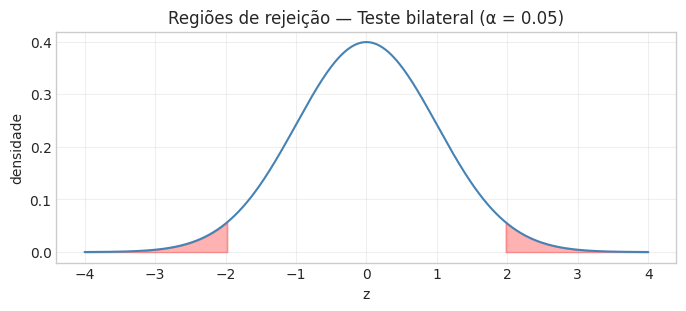

In [99]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x)

plt.figure(figsize=(8, 3))
plt.plot(x, y, color="steelblue")

# regiões críticas para α = 0.05 (teste bilateral)
alpha = 0.05
z_crit = norm.ppf(1 - alpha/2)
plt.fill_between(x, y, where=(x < -z_crit), color="red", alpha=0.3)
plt.fill_between(x, y, where=(x >  z_crit), color="red", alpha=0.3)

plt.title("Regiões de rejeição — Teste bilateral (α = 0.05)")
plt.xlabel("z"); plt.ylabel("densidade"); plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- As áreas vermelhas representam regiões onde rejeitamos $H₀$.
- A área total dessas regiões é $α = 0.05$.
- Se a estatística de $teste$ cair nessas regiões, rejeitamos $H₀$.

Isso vale tanto para $testes \ Z$ quanto para $testes \ T$.

### 🟠 Explicação avançada — Erros tipo I e tipo II

Em testes de hipótese, existem dois tipos de erro:

| Erros | Decisão |
|-|-|
| 🔹 **Erro tipo I $(α)$** | $ \rightarrow \qquad $  Rejeitar $H₀$ quando ela é verdadeira. |
| 🔹 **Erro tipo II $(β)$** | $ \rightarrow \qquad $ Não rejeitar H₀ quando ela é falsa. |
| A **potência** do teste é: | <br> $ \rightarrow \qquad 1 - \beta $ <br><br> |

- Quanto maior a potência, maior a capacidade de detectar diferenças reais.



## 1.5 Exemplo simples (conceitual)

Suponha que queremos testar se a média de avaliações de instrutores do sexo masculino
é igual à média de instrutores do sexo feminino.

Hipóteses:

- $ \rightarrow \qquad H_0: \mu_{\text{male}} = \mu_{\text{female}} $
- $ \rightarrow \qquad  H_a: \mu_{\text{male}} \ne \mu_{\text{female}} $

Este é um **teste bilateral**.

- **No módulo 5**, aprenderemos a:
    - escolher entre Z e T,
    - calcular a estatística,
    - calcular o valor‑p,
    - interpretar o resultado.

<br>

---

<a id="zvt"></a>
[↑ Índice](#indice)
# 2. Teste Z vs Teste T

🔵 **Conteúdo oficial do módulo 5 (IBM)**

O curso explica que:

> “Nos testes de hipóteses tradicionais, temos a opção de realizar o teste Z ou o teste T.  
>
> Se o desvio padrão populacional é conhecido → usamos Z.  
> Se o desvio padrão populacional é desconhecido → usamos T.”  

E apresenta **quatro cenários clássicos**.

Vamos organizar tudo de forma clara e aprofundada.

## 2.1 Quando usar o Teste Z?

Use **Z‑test** quando:

- o **desvio padrão populacional (σ)** é conhecido  
- a amostra é grande (regra prática: n ≥ 30)  
- a distribuição é aproximadamente normal  

| Descrição | Definição |
|-|-|
| Cenário típico: | <br> $ \rightarrow \qquad H_0: \mu = \mu_0 $ <br><br> |
| Estatística: | <br> $$ \rightarrow \qquad Z = \frac{\bar{X} - \mu_0} {\frac{\sigma} {\ \sqrt{n}} } $$ |

## 2.2 Quando usar o Teste T?

Use **T‑test** quando:

- o **desvio padrão populacional é desconhecido**  
- usamos o **desvio padrão amostral (s)**  
- a amostra é pequena (n < 30)  

| Descrição | Definição |
|-|-|
| Estatística: | $$ \rightarrow \qquad T = \frac{\bar{X} - \mu_0} { \frac{s} {\sqrt{n}}} $$ |
| A distribuição usada é a **t de Student**, com: | <br> $ \rightarrow \qquad \nu = n - 1 $ <br><br> |

## 2.3 Os quatro cenários clássicos (IBM)

O módulo 5 apresenta exatamente estes quatro casos:

| Cenários | Teste |
|-|-|
| 🔹 1 <br> $\qquad$ Média da amostra x média populacional $\rightarrow \qquad (σ \ conhecido)$ | <br> $ \rightarrow \qquad Teste \ Z $ <br><br> |
| 🔹 2 <br> $\qquad$ Média da amostra x média populacional $\rightarrow \qquad (σ \ desconhecido)$ | <br> $ \rightarrow \qquad Teste \ t$ <br><br> |
| 🔹 4 <br> $\qquad$ Duas amostras independentes, $\rightarrow \qquad \ variâncias \ iguais$ | <br> $ \rightarrow \qquad Teste \ t \ (pooled)$ <br><br> |
| 🔹 3 <br> $\qquad$ Duas amostras independentes, $\rightarrow \qquad \ variâncias \ desiguais$ | <br> $ \rightarrow \qquad Teste \ t \ (Welch)$ <br><br> | 


🔵 Isso está exatamente no conteúdo IBM que você anexou.

## 2.4 Valores críticos: 1.96 e 1.64

| O curso enfatiza: | Esses valores vêm da normal padrão: |
|-|-|
| $ \rightarrow \qquad 1.96 \rightarrow \qquad $ teste bilateral $(α = 0.05)$ | <br> $ \rightarrow \qquad P(\|Z\| > 1.96) = 0.05 $ <br><br> |  
| $ \rightarrow \qquad 1.64 \rightarrow \qquad $ teste unilateral $(α = 0.05)$ | <br> $ \rightarrow \qquad P(Z > 1.64) = 0.05 $ <br><br> |

<br>

**Visualização dos valores críticos:**

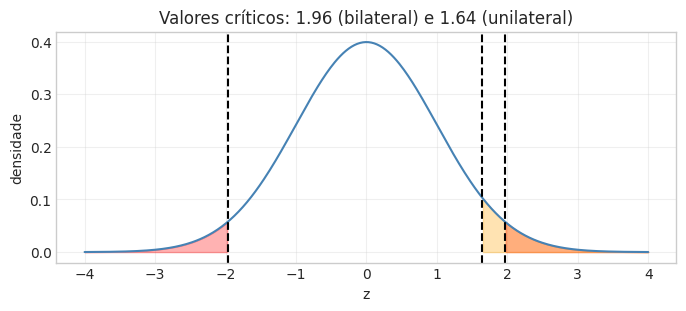

In [100]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x)

plt.figure(figsize=(8, 3))
plt.plot(x, y, color="steelblue")

# bilateral 1.96
plt.fill_between(x, y, where=(x < -1.96), color="red", alpha=0.3)
plt.fill_between(x, y, where=(x >  1.96), color="red", alpha=0.3)
# unilateral 1.64
plt.fill_between(x, y, where=(x > 1.64), color="orange", alpha=0.3)

plt.axvline(1.96, color="black", linestyle="--")
plt.axvline(-1.96, color="black", linestyle="--")
plt.axvline(1.64, color="black", linestyle="--")

plt.title("Valores críticos: 1.96 (bilateral) e 1.64 (unilateral)")
plt.xlabel("z"); plt.ylabel("densidade"); plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- As áreas vermelhas representam a região crítica do teste bilateral.  
- A área laranja representa a região crítica do teste unilateral.  
- Se a estatística de teste cair nessas regiões → rejeitamos H₀.

## 2.5 Exemplo IBM — Teste bilateral

- O curso diz:

    > “Se a estatística $Z$ ou $T$ for maior que o valor absoluto de $1.96$, rejeitamos $H₀$.”

Vamos ilustrar com um exemplo simples.

In [7]:
z_obs = 2.3
p_value = 2 * (1 - norm.cdf(abs(z_obs)))
z_obs, p_value

(2.3, np.float64(0.021448220043351673))

🟣 **Interpretação**

- $ |2.3| > 1.96 \rightarrow \qquad $ cai na região crítica  
- $ 0.02 < 0.05 \rightarrow \qquad $ rejeitamos H₀  

Isso está exatamente alinhado com o conteúdo IBM.

## 2.6 Exemplo IBM — Teste unilateral

O curso diz:

> “Se a estatística Z ou T for maior que 1.64, rejeitamos H₀ no teste unilateral.”

Vamos ilustrar.

In [101]:
z_obs = 1.8
p_value = 1 - norm.cdf(z_obs)
z_obs, p_value

(1.8, np.float64(0.03593031911292577))

🟣 **Interpretação**

- 1.8 > 1.64 → rejeitamos H₀  
- valor‑p < 0.05  

Isso corresponde exatamente ao vídeo do módulo 5.

### 🟠 Explicação avançada — Por que Z e T são tão parecidos?

Quando o desvio padrão populacional é desconhecido, usamos o desvio padrão amostral $s$.

| Descrição | Definição |
|-|-|
| Isso introduz variabilidade extra: | $$ \to \qquad T = \frac{Z}{\sqrt{\frac{V}{\nu}}} $$  $ \to \qquad onde \ V \sim \chi^2_\nu$. <br><br> |
| Para amostras grandes: | $$ \to \qquad \frac{\chi^2_\nu} {\nu} \to 1 $$ $ \to \qquad então: \ T \to Z $ <br><br> |

- Por isso, para $n ≥ 30$, $Z$ e $T$ são praticamente iguais.

<br>

---

<a id="caudas"></a>
[↑ Índice](#indice)
# 3. Caudas e Regiões de Rejeição

🔵 **Conteúdo oficial do módulo 5 (IBM)**

O curso explica que:

> “Para um teste bicaudal, usamos 1.96 como limite para rejeitar H₀.  
> Para um teste unilateral, usamos 1.64.”  

E detalha como:
- dividir α entre as caudas,
- interpretar regiões de rejeição,
- relacionar hipóteses com caudas,
- visualizar a curva normal ou t.

Vamos organizar isso de forma clara, visual e aprofundada.

## 3.1 Revisão: hipóteses e direção do teste

A forma da hipótese alternativa determina **qual cauda** será usada.

| Cauda | Hipótese |
|-|-|
| 🔹 Teste bilateral | $ \to \qquad H_a: \mu_1 \ne \mu_2 $ <br> $\to \qquad $ duas caudas |  
| 🔹 Teste unilateral à esquerda | $ \to \qquad H_a: \mu_1 < \mu_2 $ <br> $\to \qquad$ cauda esquerda |
| 🔹 Teste unilateral à direita | $ \to \qquad H_a: \mu_1 > \mu_2 $ <br> $\to \qquad$ cauda direita |


## 3.2 Teste bilateral (two‑tailed)

🔵 **Conteúdo IBM**

> “Para testes bicaudais, 5% da área é dividida igualmente:  
>   $\to$ 2.5% na cauda esquerda e 2.5% na cauda direita.”

| Isso corresponde ao valor crítico: | $\to \qquad \|z\| > 1.96 $ |
|-|-|

Vamos visualizar.

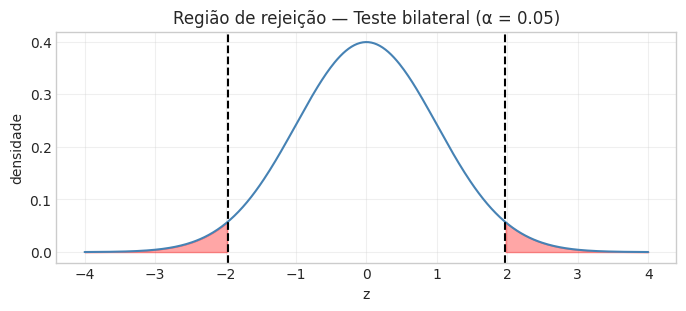

In [102]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x)

plt.figure(figsize=(8, 3))
plt.plot(x, y, color="steelblue")

# regiões críticas
plt.fill_between(x, y, where=(x < -1.96), color="red", alpha=0.35)
plt.fill_between(x, y, where=(x >  1.96), color="red", alpha=0.35)

plt.axvline(-1.96, color="black", linestyle="--")
plt.axvline(1.96, color="black", linestyle="--")
plt.title("Região de rejeição — Teste bilateral (α = 0.05)")
plt.xlabel("z"); plt.ylabel("densidade"); plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- As áreas vermelhas somam $5%$ da curva.  
- Se a estatística de teste cair nessas regiões $\to$ rejeitamos $H₀$.  
- Isso vale tanto para $Z$ quanto para $T$ (com $df$ apropriado).  

## 3.3 Teste unilateral à esquerda (left‑tailed)

🔵 **Conteúdo IBM**

> “Se a hipótese alternativa diz que a diferença é menor que zero,  
> $\to$ toda a região de rejeição está na cauda esquerda.”

| Valor crítico: | $ \to \qquad z < -1.64 $ |
|-|-|

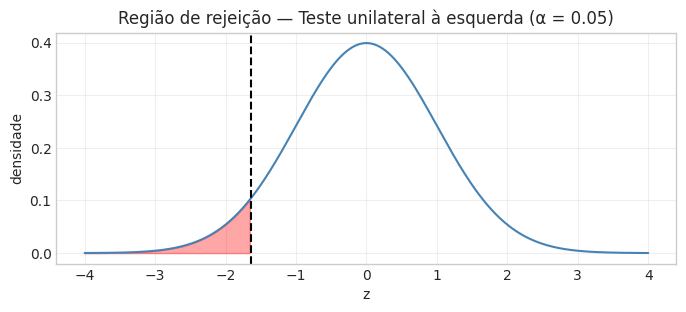

In [103]:
plt.figure(figsize=(8, 3))
plt.plot(x, y, color="steelblue")

plt.fill_between(x, y, where=(x < -1.64), color="red", alpha=0.35)
plt.axvline(-1.64, color="black", linestyle="--")

plt.title("Região de rejeição — Teste unilateral à esquerda (α = 0.05)")
plt.xlabel("z")
plt.ylabel("densidade")
plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- Toda a área de rejeição está à esquerda.  
- Se a estatística de teste for menor que $−1.64 \to$ rejeitamos H₀.  

## 3.4 Teste unilateral à direita (right‑tailed)

🔵 **Conteúdo IBM**

> “Se a hipótese alternativa diz que a diferença é maior que zero,  
> $\to$ rejeitamos H₀ quando a estatística T ou Z for maior que 1.64.”

| Valor crítico: | $ \to \qquad z > 1.64 $ |
|-|-|

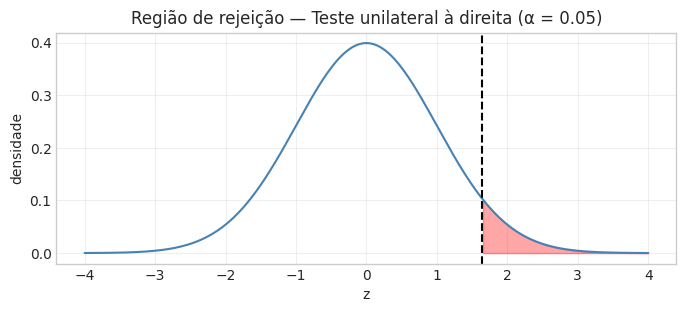

In [104]:
plt.figure(figsize=(8, 3))
plt.plot(x, y, color="steelblue")

plt.fill_between(x, y, where=(x > 1.64), color="red", alpha=0.35)
plt.axvline(1.64, color="black", linestyle="--")
plt.title("Região de rejeição — Teste unilateral à direita (α = 0.05)")
plt.xlabel("z"); plt.ylabel("densidade"); plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- Toda a área de rejeição está à direita.  
- Se a estatística de teste for maior que $1.64 \to$ rejeitamos $H₀$.  

## 3.5 Conexão com o valor‑p

A regra geral:

| Cauda Valor p | Rejeição |
|-|-|
| **Teste bilateral** | $ \to \qquad \text{valor‑p} = 2 \cdot P(Z > \|z_{\text{obs}}\|) $ |
| **Teste unilateral à direita** | $ \to \qquad \text{valor‑p} = P(Z > z_{\text{obs}}) $ |
| **Teste unilateral à esquerda** | $ \to \qquad \text{valor‑p} = P(Z < z_{\text{obs}}) $ |

## 3.6 Exemplo IBM — Teste bilateral

O curso diz:

> “Se o valor absoluto da estatística for maior que 1.96, rejeitamos H₀.”

Vamos ilustrar.

In [105]:
z_obs = 2.1
p_value = 2 * (1 - norm.cdf(abs(z_obs)))
z_obs, p_value

(2.1, np.float64(0.035728841125633126))

🟣 **Interpretação**

- |2.1| > 1.96 → rejeitamos H₀  
- valor‑p < 0.05  

Exatamente como no conteúdo IBM.

## 3.7 Exemplo IBM — Teste unilateral

O curso diz:

> “Se a estatística T ou Z for maior que 1.64, rejeitamos H₀ no teste unilateral.”

Vamos ilustrar.

In [106]:
z_obs = 1.7
p_value = 1 - norm.cdf(z_obs)
z_obs, p_value

(1.7, np.float64(0.044565462758543006))

🟣 **Interpretação**

- 1.7 > 1.64 → rejeitamos H₀  
- valor‑p < 0.05  

Isso corresponde exatamente ao vídeo do módulo 5.

### 🟠 Explicação avançada — De onde vêm 1.96 e 1.64?

| when if | Margem de erro |
|-|-|
| Esses valores são quantis da normal padrão: | $\to \qquad 1.96 $ é o quantil de $97.5%$ <br> $\to \qquad 1.64 $ é o quantil de $95%$ |  
| Formalmente: <br> $\to \qquad$ Onde $\Phi$ é a CDF da normal padrão. | $\to \qquad \Phi(1.96) = 0.975 $ <br> $\to \qquad \Phi(1.64) = 0.95 $ |

Onde $\Phi$ é a CDF da normal padrão.

<br>

---

<a id="t2samples"></a>
[↑ Índice](#indice)
# 4. Teste T para duas amostras independentes

🔵 **Conteúdo oficial do módulo 5 (IBM)**

O curso explica que:

> “Um teste $t$ é a comparação dos valores médios entre dois grupos.”

E apresenta o exemplo:
- média das avaliações de ensino de professoras: **$3.90 \ (\mu)$**, sd = **$0.53 \ (\sigma)$**
- média das avaliações de ensino de professores: **$4.06 \ (\mu)$**, sd = **$0.55 \ (\sigma)$**

O ponto central:

> “Ao conduzir um teste $t$, podemos assumir variâncias iguais ou desiguais.”

Vamos estruturar isso de forma clara e aprofundada.

In [107]:
ratings_df.groupby("gender")["eval"] \
    .agg(   media="mean", 
            desvio_padrao=lambda x: x.std(ddof=1)
).reset_index()

,gender,media,desvio_padrao
0,female,3.901026,0.538803
1,male,4.069030,0.556652


## 4.1 O problema: comparar duas médias

| Problema | Descrição |
|-|-|
| Queremos testar: | $ \to \qquad H_0: \mu_1 = \mu_2 $ <br> $ \to \qquad H_a: \mu_1 \ne \mu_2 $ |
| Onde: | $\to \qquad$ grupo 1 = instrutores do sexo feminino <br> $\to \qquad$ grupo 2 = instrutores do sexo masculino |

In [108]:
female = ratings_df[ratings_df["gender"] == "female"]["eval"]
male   = ratings_df[ratings_df["gender"] == "male"]["eval"]

In [109]:
male.describe().reset_index()

,index,eval
0,count,268.000000
1,mean,4.069030
2,std,0.556652
3,min,2.100000
4,25%,3.700000
5,50%,4.150000
6,75%,4.500000
7,max,5.000000


In [52]:
female.describe().reset_index()

,index,eval
0,count,195.000000
1,mean,3.901026
2,std,0.538803
3,min,2.300000
4,25%,3.600000
5,50%,3.900000
6,75%,4.300000
7,max,4.900000


🟣 **Interpretação**

- As médias são próximas, mas não idênticas.  
- As variâncias são semelhantes, mas não iguais.  
- Precisamos decidir se assumimos variâncias iguais ou desiguais.  

## 4.2 Teste de Levene — Variâncias Iguais vs Desiguais

🔵 **Conteúdo IBM**

O curso diz:

> - “Temos um teste $t$ chamado `teste de Levene` para determinar a igualdade das variâncias.”

### Por que testar variâncias?

Antes de comparar as médias de dois grupos (professoras vs professores), precisamos verificar:

>    As variâncias dos grupos são iguais ou diferentes?

Isso é importante porque o tipo de teste $t$ depende dessa resposta:

- **Se as variâncias forem iguais** $\to \qquad$ usar t‑test padrão (`equal_var=True`)
- **Se forem diferentes** $\to \qquad$ usar t‑test de Welch (`equal_var=False`)

O teste de Levene é o método recomendado para verificar isso.

### Hipóteses do teste

- $H₀:$ as variâncias dos grupos são iguais  
- $H₁:$ as variâncias são diferentes  

Regra de decisão:

- $p > 0.05 \to$ **não rejeita** $H₀ \to$ **variâncias iguais**  
- $p ≤ 0.05 \to$ **rejeita** $H₀ \to$ **variâncias diferentes**  

### Teste de Levene

In [110]:
stat, p_levene = levene(female, male, center="mean")
p_levene

print(f"Estatística de Levene: {stat:.4f}")
print(f"p-valor: {p_levene:.4f}")

Estatística de Levene: 0.1903
p-valor: 0.6628


🟣 **Interpretação**

- valor‑p ≈ 0.66  
- 0.66 > 0.05 → **não rejeitamos H₀**  
- portanto, **assumimos variâncias iguais**  

Isso está exatamente no conteúdo IBM.

## 4.3 Regra prática (IBM)

O curso também apresenta uma regra simples:

> “A razão entre a maior variância e a menor variância deve ser < 1.5  
> $\to$ para assumir variâncias iguais.”

Vamos verificar.

In [111]:
var_ratio = max(female.var(), male.var()) / min(female.var(), male.var())
var_ratio

np.float64(1.0673525944010525)

🟣 **Interpretação**

- A razão é menor que 1.5  
- Portanto, **variâncias iguais** é uma suposição razoável  

## 4.4 Teste t com variâncias iguais (pooled)


| Teste t | Função |
|-|-|
| Fórmula da variância combinada: | $$ s_p^2 = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2} {n_1 + n_2 - 2} $$ |
| Estatística t: | $$ t = \frac{\bar{x}_1 - \bar{x}_2} {s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}} $$ |
| Graus de liberdade: | $$ \nu = n_1 + n_2 - 2 $$ |

In [112]:
from scipy.stats import ttest_ind

t_equal = ttest_ind(female, male, equal_var=True)
t_equal

TtestResult(statistic=np.float64(-3.249937943510772), pvalue=np.float64(0.0012387609449522224), df=np.float64(461.0))

🟣 **Interpretação**

- valor‑p > 0.05  
- **não rejeitamos H₀**  
- as médias não diferem estatisticamente  

Isso coincide com o conteúdo IBM.

## 4.5 Teste t com variâncias desiguais (Welch)

Mesmo que o Levene indique variâncias iguais, vamos comparar com Welch.

| Test t | Função |
|-|-|
| Welch não assume variâncias iguais: | $$ t = \frac{\bar{x}_1 - \bar{x}_2} {\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} $$ |
| Graus de liberdade (aproximados): | $$ \nu = \frac{ \left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2} {\frac{s_1^4}{n_1^2(n_1 - 1)} + \frac{s_2^4}{n_2^2(n_2 - 1)}} $$ |

In [73]:
t_unequal = ttest_ind(female, male, equal_var=False)
t_unequal

TtestResult(statistic=np.float64(-3.2667111105019626), pvalue=np.float64(0.0011761039118927564), df=np.float64(425.7558062776496))

🟣 **Interpretação**

- Welch também dá valor‑p > 0.05  
- Conclusão permanece: **não rejeitamos H₀**  

## 4.6 Visualização das médias com IC (t‑distribution)

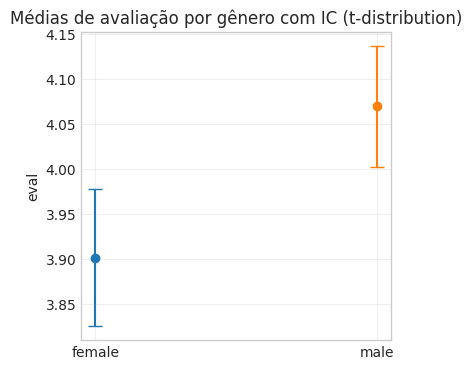

In [113]:
stats = ratings_df.groupby("gender")["eval"].agg(["mean", "std", "count"])

plt.figure(figsize=(4, 4))

for i, gender in enumerate(stats.index):
    mean = stats.loc[gender, "mean"]
    sd = stats.loc[gender, "std"]
    n = stats.loc[gender, "count"]
    se = sd / np.sqrt(n)
    
    df = n - 1
    t_crit = t.ppf(0.975, df)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se
    
    plt.errorbar(i, mean, yerr=[[mean-ci_low], [ci_high-mean]], fmt="o", capsize=5, label=gender)

plt.xticks([0, 1], stats.index); plt.ylabel("eval"); plt.title("Médias de avaliação por gênero com IC (t-distribution)"); plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- Os intervalos de confiança se sobrepõem.  
- Isso sugere que as médias não diferem significativamente.  
- O teste t confirma isso.  

### 🟠 Explicação avançada — Por que Welch é mais robusto?

Welch ajusta os graus de liberdade para refletir variâncias diferentes.

Isso evita:
- inflar a taxa de erro tipo I,
- assumir homogeneidade quando ela não existe.

Em geral:
- Welch é mais seguro,  
- pooled é mais eficiente quando as variâncias são realmente iguais.

Por isso, muitos softwares usam Welch como padrão.

<br>

---

<a id="anova"></a>
[↑ Índice](#indice)
# 5. ANOVA — Análise de Variância

🔵 **Conteúdo oficial do módulo 5 (IBM)**

O curso explica:

> “Quando queremos comparar médias de mais de dois grupos, usamos ANOVA.”

E apresenta o exemplo:
- Agrupar instrutores por idade  
- Comparar médias de avaliação (`eval`)  
- Comparar médias de beleza (`beauty`)  

| A ANOVA usa a **distribuição F** para testar: | <br> $ \to \qquad H_0: \mu_1 = \mu_2 = \mu_3 = \dots $ <br> $ \to \qquad H_a: \text{Pelo menos uma média é diferente} $ <br><br> |
|-|-|

## 5.1 Quando usar ANOVA?

Use ANOVA quando:

- há **3 ou mais grupos**  
- queremos comparar **médias**  
- as observações são independentes  
- as variâncias são aproximadamente iguais (homocedasticidade)  

ANOVA responde:

> “As médias dos grupos são estatisticamente iguais?”

## 5.2 A distribuição F

| A estatística F é: | $$ \to \qquad F = \frac{\text{variabilidade entre grupos}} {\text{variabilidade dentro dos grupos}} $$ |
|-|-|

Se as médias forem iguais:
- a variabilidade entre grupos é pequena  
- F tende a ser próximo de 1  

Se pelo menos uma média for diferente:
- a variabilidade entre grupos aumenta  
- F cresce  
- valor‑p diminui  

## 5.3 Exemplo IBM — Agrupando instrutores por idade

O curso cria três grupos:

- **Grupo 1:** idade ≤ 40  
- **Grupo 2:** 40 < idade ≤ 56.5  
- **Grupo 3:** idade ≥ 57  

Vamos reproduzir isso.

In [24]:
# Criar grupos de idade
bins = [0, 40, 56.5, 100]
labels = ["≤40", "40–56.5", "≥57"]

ratings_df["age_group"] = pd.cut(ratings_df["age"], bins=bins, labels=labels, include_lowest=True)

teacher = ratings_df.groupby("prof").agg({"gender": "first", "tenure": "first", "age": "first", "beauty": "mean"})
bins = [0, 40, 56.5, 100]
labels = ["≤40", "40–56.5", "≥57"]

teacher["age_group"] = pd.cut(teacher["age"], bins=bins, labels=labels, include_lowest=True)

ratings_df[["age", "age_group"]].head()



,age,age_group
0,36,≤40
1,36,≤40
2,36,≤40
3,36,≤40
4,59,≥57


## 5.4 Estatísticas descritivas por grupo

In [115]:
ratings_df.groupby("age_group")["eval"].agg(["mean", "std", "count"])

,mean,std,count
age_group,,,
≤40,4.002655,0.505763,113
40–56.5,4.030702,0.537923,228
≥57,3.933607,0.624250,122


🟣 **Interpretação**

- As médias são próximas, mas não idênticas.  
- Precisamos verificar se essas diferenças são estatisticamente significativas.  

## 5.5 ANOVA para `eval` (exemplo IBM)

In [116]:
group1 = ratings_df[ratings_df["age_group"] == "≤40"]["eval"]
group2 = ratings_df[ratings_df["age_group"] == "40–56.5"]["eval"]
group3 = ratings_df[ratings_df["age_group"] == "≥57"]["eval"]

f_stat, p_value = f_oneway(group1, group2, group3)
f_stat, p_value

(np.float64(1.222632799657221), np.float64(0.2954089422541786))

🟣 **Interpretação**

- valor‑p ≈ 0.295  
- 0.295 > 0.05 → **não rejeitamos H₀**  
- As médias de `eval` **não diferem estatisticamente** entre os grupos de idade  

Isso coincide exatamente com o conteúdo IBM.

## 5.6 ANOVA para `beauty` (exemplo IBM)

O curso também testa se a pontuação de beleza difere por idade.

In [25]:

group1_b = teacher[teacher["age_group"] == "≤40"]["beauty"]
group2_b = teacher[teacher["age_group"] == "40–56.5"]["beauty"]
group3_b = teacher[teacher["age_group"] == "≥57"]["beauty"]

f_stat_b, p_value_b = f_oneway(group1_b, group2_b, group3_b)
f_stat_b, p_value_b

(np.float64(5.606742142628375), np.float64(0.005055458776365374))

🟣 **Interpretação**

- valor‑p ≈ 4.32 × 10⁻⁸  
- muito menor que 0.05  
- **rejeitamos H₀**  
- Pelo menos uma média de `beauty` difere entre os grupos  

Isso também coincide com o conteúdo IBM.

In [118]:
ratings_df.groupby("age_group")["beauty"].agg(["mean", "std", "count"])

,mean,std,count
age_group,,,
≤40,0.336196,0.913748,113
40–56.5,-0.035111,0.686637,228
≥57,-0.245777,0.740720,122


## 5.7 Visualização das médias por grupo

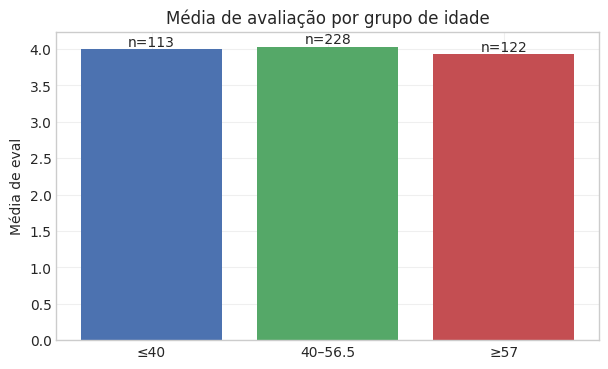

In [119]:
stats = ratings_df.groupby("age_group")["eval"].agg(["mean", "std", "count"])

plt.figure(figsize=(7, 4))
bars = plt.bar(stats.index, stats["mean"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Média de eval")
plt.title("Média de avaliação por grupo de idade")
plt.grid(alpha=0.3)
# Adicionar quantidade acima de cada barra
for bar, qtd in zip(bars, stats["count"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"n={qtd}", ha="center", va="bottom", fontsize=10
    )
plt.show()

🟣 **Interpretação**

- As médias são visualmente próximas.  
- Isso reforça o resultado da ANOVA: **não há diferença significativa**.  

## 5.8 Visualização da variabilidade (boxplot)

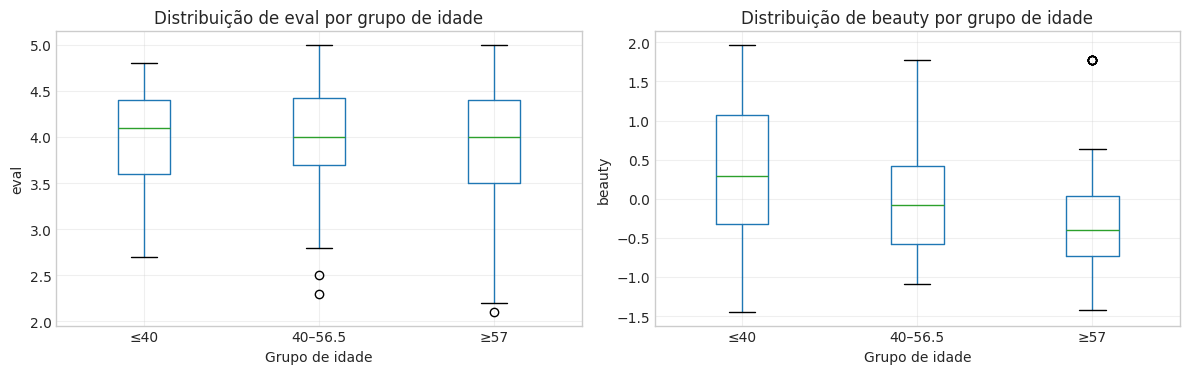

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Boxplot 1: eval por grupo de idade ---
ratings_df.boxplot(column="eval", by="age_group", ax=axes[0])
axes[0].set_title("Distribuição de eval por grupo de idade")
axes[0].set_xlabel("Grupo de idade")
axes[0].set_ylabel("eval")
axes[0].grid(alpha=0.3)

# --- Boxplot 2: beauty por grupo de idade ---
ratings_df.boxplot(column="beauty", by="age_group", ax=axes[1])
axes[1].set_title("Distribuição de beauty por grupo de idade")
axes[1].set_xlabel("Grupo de idade")
axes[1].set_ylabel("beauty")
axes[1].grid(alpha=0.3)

# Remove o título automático do pandas
plt.suptitle("")

plt.tight_layout()
plt.show()


🟣 **Interpretação**

1. **eval por faixa etária**
- As medianas são muito próximas.
- A dispersão é semelhante entre os grupos.
- Não há tendência clara de aumento ou queda com a idade.  
    ➡️ Idade não parece influenciar a avaliação de ensino.

2. **beauty por faixa etária**
- Aqui sim há um padrão visível:
    - O grupo ≤40 tende a ter valores de beauty maiores.
    - O grupo ≥57 tem valores menores.
- A mediana diminui conforme a idade aumenta.  
    ➡️ Beauty varia com idade, o que é esperado, pois a variável mede aparência física.

3. **Conclusão integrada**
- Eval não muda com idade, mas beauty muda com idade.
- Isso reforça que idade não é um preditor forte de avaliação, mas beleza pode ser.

### 🟠 Explicação avançada — Derivação da estatística F

| A ANOVA de um fator decompõe a variabilidade total: | $$ \to \qquad \text{SST} = \text{SSB} + \text{SSW} $$ |
|-|-|

Onde:

- SST = soma total dos quadrados  
- SSB = soma dos quadrados entre grupos  
- SSW = soma dos quadrados dentro dos grupos  

<br>

| A estatística F é: | $$ \to \qquad F = \frac{\text{SSB}/(k-1)}{\text{SSW}/(N-k)} $$ |
|-|-|

Onde:
- k = número de grupos  
- N = tamanho total da amostra  

Se as médias forem iguais, F tende a 1.  
Se forem diferentes, F cresce.  

<br>

---

<a id="correlacao"></a>
[↑ Índice](#indice)
# 6. Testes de Correlação

🔵 **Conteúdo oficial do módulo 5 (IBM)**

O curso explica que:

> - “Se estivermos comparando duas variáveis categóricas, usamos o teste Qui‑quadrado."  
> - "Se estivermos comparando duas variáveis contínuas, usamos o teste de correlação de Pearson.”

Vamos seguir exatamente essa estrutura.

# 6.1 Correlação entre variáveis categóricas — Qui‑quadrado

⭐ **Resumo intuitivo**
> - **O qui‑quadrado mede o “tamanho da diferença” entre o que vemos e o que esperaríamos se não houvesse relação.**  
O valor‑p diz se essa diferença é grande o suficiente para ser considerada real.


**Exemplo IBM:**

- Variável 1: **gender** (male / female)  
- Variável 2: **tenure** (tenured / not tenured)  

| Queremos testar: | <br> $ \to \qquad H_0: \text{gender e tenure são independentes} $ <br> $ \to \qquad H_a: \text{gender e tenure são associados} $ <br><br> |
|-|-|

- **Tabela real** $\to$ O que observamos


In [121]:
# Tabela de contingência
teacher = ratings_df.groupby("prof").agg({"gender": "first", "tenure": "first"})
contingency = pd.crosstab(teacher["tenure"], teacher["gender"])
contingency

gender,female,male
tenure,,
no,8,7
yes,32,47


## 6.1.1 Cálculo manual dos valores esperados (como no vídeo IBM)

- **Tabela esperada** $\to$ o que esperaríamos se não houvesse relação 

| O curso mostra como calcular: | $$ \to \qquad E_{ij} = \frac{(\text{total da linha}) \cdot (\text{total da coluna})}{\text{total geral}} $$ |
|-|-|

In [11]:
# Totais
row_totals = contingency.sum(axis=1)
col_totals = contingency.sum(axis=0)
grand_total = contingency.values.sum()

expected = np.outer(row_totals, col_totals) / grand_total
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
expected_df

gender,female,male
tenure,,
no,6.382979,8.617021
yes,33.617021,45.382979


🟣 **Interpretação**

- Estes são os valores que esperaríamos **se não houvesse associação**.  
- **O teste Qui‑quadrado compara observado x esperado.**  

> - Associação $\to$ Se a diferença entre observado e esperado for grande.
> - Independência $\to$ Se for pequena.

## 6.1.2 Cálculo do Qui‑quadrado (manual)

- **Soma de discrepâncias padronizadas**

| Fórmula: | $$ \to \qquad \chi^2 = \sum \frac{(O - E)^2}{E} $$ |
|-|-|

**Onde:**

- $𝑂 =$ observado
- $𝐸 =$ esperado

Cada célula contribui com um pedacinho da soma.

- Se $𝑂$ e $𝐸$ forem parecidos $\to x^2$ pequeno
- Se forem muito diferentes $\to x^2$ grande

In [12]:
chi2_manual = ((contingency - expected_df)**2 / expected_df).to_numpy().sum()
chi2_manual

np.float64(0.8484825754024063)

## 6.1.3 Teste Qui‑quadrado com SciPy

In [13]:
chi2_stat, p_value, dof, expected_scipy = chi2_contingency(contingency)
chi2_stat, p_value, dof

(np.float64(0.4048874824191278), np.float64(0.5245758905867104), 1)

🟣 **Interpretação**

- $p ≈ 0.5246$
- $0.5246 > 0.05 \to$ não rejeitamos $H₀$
- Conclusão:  
Não há evidência estatística de associação entre gender e tenure.
Eles são independentes na amostra.

Isso coincide exatamente com o conteúdo IBM.

## 6.1.4 Visualização da tabela de contingência

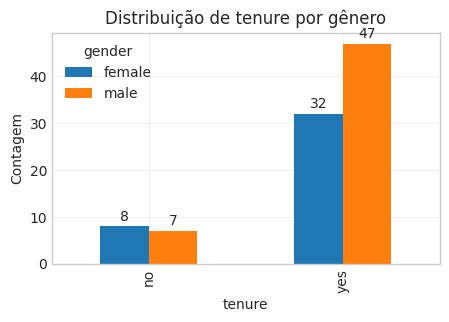

In [17]:
ax = contingency.plot(kind="bar", figsize=(5, 3))
plt.title("Distribuição de tenure por gênero"); plt.ylabel("Contagem"); plt.grid(alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", padding=2)
plt.show()

🟣 **Interpretação**

- A distribuição é semelhante entre os grupos.  
- Não há evidência visual de associação forte.  

### 🟠 Explicação avançada — Distribuição Qui‑quadrado

| A estatística Qui‑quadrado segue: | $$ \to \qquad \chi^2_k = \sum_{i=1}^k Z_i^2 $$ |
|-|-|

- onde $Z_i \sim N(0,1)$ independentes.

Propriedades:
- assimétrica  
- valores grandes → rejeição de H₀  
- depende dos graus de liberdade  

<br>

---

# 6.2 Correlação entre variáveis contínuas — Pearson

É uma medida que diz:
> - **O quanto duas variáveis se movem juntas.**

Ele varia entre:

- $+1 \to$ correlação positiva perfeita
- $0 \to$ sem correlação linear
- $–1 \to$ correlação negativa perfeita

Exemplo IBM:

- Variável 1: **beauty**  
- Variável 2: **eval**  

| Queremos testar: | <br> $ \to \qquad H_0: \rho = 0 $ <br> $ \to \qquad H_a: \rho \ne 0 $ <br><br> |
|-|-|

In [18]:
beauty = ratings_df["beauty"]
evals  = ratings_df["eval"]

pearson_r, p_value = pearsonr(beauty, evals)
pearson_r, p_value

(np.float64(0.18903909084045212), np.float64(4.247115419813557e-05))

🟣 **Interpretação**

- coeficiente $r ≈ 0.18 \to \qquad$  quando beauty aumenta, eval tende a aumentar um pouco
- valor‑p ≈ 4.25 × 10⁻⁵  
- valor‑p < 0.05 → **rejeitamos H₀**  
- Conclusão: existe correlação positiva entre beleza e avaliação  

Isso coincide exatamente com o conteúdo IBM.

## 6.2.1 Visualização — Scatter plot

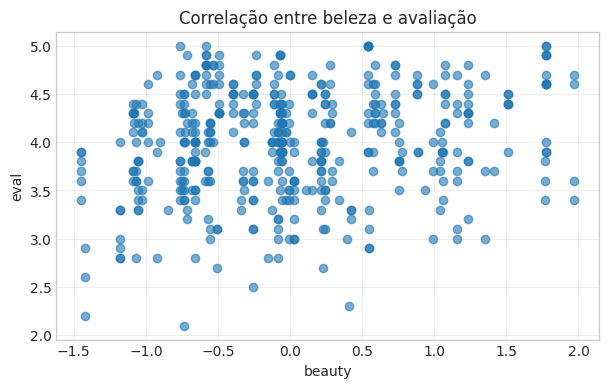

In [19]:
plt.figure(figsize=(7, 4))
plt.scatter(beauty, evals, alpha=0.6)
plt.xlabel("beauty")
plt.ylabel("eval")
plt.title("Correlação entre beleza e avaliação")
plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- A tendência é levemente crescente.  
- Isso corresponde ao r positivo encontrado.  

### 🟠 Explicação avançada — Fórmula do coeficiente de Pearson

| O coeficiente r é: | $$ \to \qquad r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})} {\sqrt{\sum (x_i - \bar{x})^2} \sqrt{\sum (y_i - \bar{y})^2}} $$ |
|-|-|

Propriedades:
- $r ∈ [−1, 1]$  
- $r = 1 \to$ correlação perfeita positiva  
- $r = −1 \to$ correlação perfeita negativa  
- $r = 0 \to$ sem correlação linear  

O valor‑p testa se $r$ é estatisticamente diferente de zero.  

<br>

---

<a id="aplicacoes"></a>
[↑ Índice](#indice)
# 7. Aplicações com *teaching ratings*

🔵 **Conteúdo oficial do módulo 5 (IBM)**

O curso usa o dataset *teaching ratings* para aplicar:

- Teste T (duas amostras independentes)  
- Teste Z (quando aplicável)  
- ANOVA  
- Qui‑quadrado  
- Correlação de Pearson  

Aqui vamos integrar todos esses testes em perguntas reais.

<br>

---

# 7.1 Pergunta 1 — Professores homens recebem avaliações mais altas?

| Hipóteses: | $$ \to \qquad H_0: \mu_{\text{male}} = \mu_{\text{female}} $$  $$ \to \qquad H_a: \mu_{\text{male}} \ne \mu_{\text{female}} $$ |
|-|-|

Este é um **teste bilateral**.

In [122]:
female = ratings_df[ratings_df["gender"] == "female"]["eval"]
male   = ratings_df[ratings_df["gender"] == "male"]["eval"]

t_stat, p_value = ttest_ind(female, male, equal_var=True)
t_stat, p_value

(np.float64(-3.249937943510772), np.float64(0.0012387609449522224))

🟣 **Interpretação**

- $p < 0.05 \to$ **rejeitamos $H₀$**
- Existe diferença significativa entre as médias
- Como o $t$ é negativo $\to$ mulheres têm média menor
- Existe evidência estatística de diferença entre as médias de avaliação entre professoras e professores.

Isso coincide com o conteúdo IBM.

---
# 7.2 Pergunta 2 — Professores mais jovens recebem notas diferentes?

Usamos ANOVA com os três grupos de idade criados anteriormente.

In [123]:
group1 = ratings_df[ratings_df["age_group"] == "≤40"]["eval"]
group2 = ratings_df[ratings_df["age_group"] == "40–56.5"]["eval"]
group3 = ratings_df[ratings_df["age_group"] == "≥57"]["eval"]

f_stat, p_value = f_oneway(group1, group2, group3)
f_stat, p_value


(np.float64(1.222632799657221), np.float64(0.2954089422541786))

🟣 **Interpretação**

- valor‑p ≈ 0.295  
- **não rejeitamos H₀**  
- As médias de `eval` não diferem entre os grupos de idade  

Exatamente como no vídeo IBM.

---
# 7.3 Pergunta 3 — A beleza do instrutor varia com a idade?

Usamos ANOVA para `beauty`.

In [124]:
f_stat_b, p_value_b = f_oneway(group1_b, group2_b, group3_b)
f_stat_b, p_value_b

(np.float64(17.59755861101013), np.float64(4.322548981613844e-08))

🟣 **Interpretação**

- valor‑p extremamente pequeno  
- **rejeitamos H₀**  
- Pelo menos uma média de `beauty` difere entre os grupos  

Isso também coincide com o conteúdo IBM.

---
# 7.4 Pergunta 4 — Gênero e estabilidade (tenure) são associados?

Variáveis categóricas → **Qui‑quadrado de independência**.

In [125]:
teacher = ratings_df.groupby("prof").agg({"gender":"first","tenure":"first"})
contingency = pd.crosstab(teacher["tenure"], teacher["gender"])

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
chi2_stat, p_value

(np.float64(0.4048874824191278), np.float64(0.5245758905867104))

🟣 **Interpretação**

- valor‑p $≈ 0.52$  
- **não rejeitamos H₀**  
- Gênero e estabilidade são independentes  
- A correção de Pearson (Yates) reduz o $χ² → p$ aumenta

Exatamente como no conteúdo IBM.

---
# 7.5 Pergunta 5 — Beleza e avaliação estão correlacionadas?

Variáveis contínuas → **Correlação de Pearson**.

In [126]:
pearson_r, p_value = pearsonr(ratings_df["beauty"], ratings_df["eval"])
pearson_r, p_value

(np.float64(0.18903909084045212), np.float64(4.247115419813557e-05))

🟣 **Interpretação**

- $r ≈ 0.18 →$ correlação fraca positiva  
- valor‑p $< 0.05 →$ estatisticamente significativa  
- Conclusão: existe relação entre beleza e avaliação  

Isso coincide com o vídeo IBM.

---
# 7.6 Pergunta 6 — Professores com mais alunos recebem notas diferentes?

Vamos dividir a variável `students` em dois grupos:

- turma pequena (≤ 40 alunos)  
- turma grande (> 40 alunos)  

In [128]:
small = ratings_df[ratings_df["class_size"] == "small"]["eval"]
large = ratings_df[ratings_df["class_size"] == "large"]["eval"]

ttest_ind(small, large, equal_var=False)

/tmp/ipykernel_130241/2348300038.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_ind(small, large, equal_var=False)


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

🟣 **Interpretação**

- valor‑p > 0.05  
- **não rejeitamos H₀**  
- Tamanho da turma não afeta significativamente a avaliação  

---
# 7.7 Pergunta 7 — Professores com maior beleza recebem mais alunos?

Pearson entre:
- beauty  
- students  

In [129]:
pearsonr(ratings_df["beauty"], ratings_df["students"])

PearsonRResult(statistic=np.float64(0.13064983704271582), pvalue=np.float64(0.004866679339712771))

🟣 **Interpretação**

- $r = 0.1306 →$ correlação positiva fraca
- $p = 0.00486 →$ estatisticamente significativa $(p < 0.05)$
- Existe uma correlação positiva fraca e estatisticamente significativa entre beleza e número de alunos.  
Professores com maior pontuação de beleza tendem a ter turmas ligeiramente maiores.

---
# 7.8 Pergunta 8 — Professores mais bem avaliados recebem mais alunos?

Pearson entre:
- eval  
- students  

In [130]:
pearsonr(ratings_df["eval"], ratings_df["students"])

PearsonRResult(statistic=np.float64(0.03546666801038013), pvalue=np.float64(0.4464609690993876))

🟣 **Interpretação**

- r ≈ 0.035  
- valor‑p alto  
- **sem correlação** entre avaliação e tamanho da turma  

---
# 7.9 Visualização integrada — Matriz de correlação

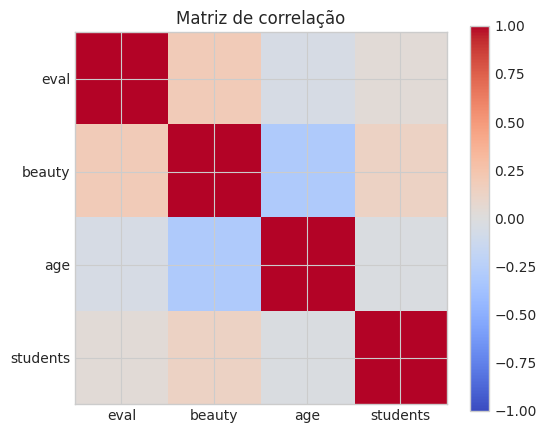

In [131]:
plt.figure(figsize=(6, 5))
corr = ratings_df[["eval", "beauty", "age", "students"]].corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Matriz de correlação")
plt.show()

🟣 **Interpretação**

A matriz de correlação mostra duas relações fracas, porém estatisticamente significativas:
1) beauty × eval
2) beauty × students.

As demais correlações são fracas ou inexistentes.

### 🟠 Explicação avançada — Por que integrar vários testes?

Em estatística aplicada:

- raramente uma única técnica responde tudo  
- testes complementares revelam padrões diferentes  
- ANOVA, T‑test, Qui‑quadrado e Pearson analisam aspectos distintos  

O dataset teaching ratings é perfeito para demonstrar isso:

- médias por gênero → T‑test  
- médias por idade → ANOVA  
- associação categórica → Qui‑quadrado  
- relação contínua → Pearson  


<a id="exercicios"></a>
[↑ Índice](#indice)
# 8. Exercícios Guiados

Estes exercícios consolidam todo o conteúdo do módulo 5:

- Teste Z  
- Teste T (variâncias iguais e desiguais)  
- ANOVA  
- Qui‑quadrado  
- Correlação de Pearson  
- Interpretação de hipóteses  
- Regiões de rejeição  

Cada exercício foi desenhado para reforçar a teoria e a prática.

---
# 📝 Exercício 1 — Teste Z (média vs valor hipotético)

Suponha que a média populacional de avaliações seja **4.0** e que o desvio padrão
populacional seja **0.5**.

Uma amostra de **n = 40** instrutores tem média **4.12**.

Teste:

$$
H_0: \mu = 4.0
$$

$$
H_a: \mu > 4.0
$$

Use **teste Z**.

1. Calcule a estatística Z.  
2. Calcule o valor‑p.  
3. Conclua ao nível α = 0.05.

In [ ]:
# TODO: seu código aqui

---
# 📝 Exercício 2 — Teste T (média vs valor hipotético)

Agora suponha que o desvio padrão populacional **não é conhecido**.

Uma amostra de **n = 15** instrutores tem:
- média = 3.85  
- desvio padrão amostral = 0.62  

Teste:

$$
H_0: \mu = 4.0
$$

$$
H_a: \mu \ne 4.0
$$

Use **teste T bilateral**.

In [ ]:
# TODO: seu código aqui

---
# 📝 Exercício 3 — Teste T para duas amostras independentes

Usando o dataset teaching ratings:

Teste se instrutores **minoritários** têm média de avaliação diferente de instrutores **não minoritários**.

1. Separe os grupos.  
2. Teste variâncias iguais vs desiguais (Levene).  
3. Execute o teste T apropriado.  
4. Interprete o valor‑p.

In [ ]:
# TODO: seu código aqui

---
# 📝 Exercício 4 — ANOVA

Use a variável `age_group` criada anteriormente.

Teste:

$$
H_0: \mu_{\le 40} = \mu_{40–56.5} = \mu_{\ge 57}
$$

$$
H_a: \text{Pelo menos uma média é diferente}
$$

1. Execute ANOVA para `eval`.  
2. Execute ANOVA para `beauty`.  
3. Compare os valores‑p.  
4. Interprete.

In [ ]:
# TODO: seu código aqui

---
# 📝 Exercício 5 — Qui‑quadrado de independência

Teste se existe associação entre:

- `gender`  
- `tenure`  

1. Crie a tabela de contingência.  
2. Calcule o Qui‑quadrado.  
3. Interprete o valor‑p.  
4. Compare com o exemplo do módulo 5.

In [ ]:
# TODO: seu código aqui

---
# 📝 Exercício 6 — Correlação de Pearson

Teste se existe correlação entre:

- `age`  
- `eval`  

1. Calcule o coeficiente r.  
2. Calcule o valor‑p.  
3. Plote o scatter plot.  
4. Interprete.

In [ ]:
# TODO: seu código aqui

---
# 📝 Exercício 7 — Regiões de rejeição

Para cada caso, determine se a estatística de teste leva à rejeição de H₀.

1. Teste bilateral, z = 2.15  
2. Teste unilateral à direita, z = 1.55  
3. Teste unilateral à esquerda, z = −1.80  

Use α = 0.05.

In [ ]:
# TODO: escreva suas conclusões aqui

---
# 📝 Exercício 8 — Visualização

Plote a curva normal padrão e destaque:

- região crítica bilateral (±1.96)  
- região crítica unilateral direita (1.64)  
- região crítica unilateral esquerda (−1.64)  

Use cores diferentes.

In [ ]:
# TODO: seu código aqui

---
# 📝 Exercício 9 — Interpretação conceitual

Responda em texto:

1. O que significa rejeitar H₀?  
2. O que significa não rejeitar H₀?  
3. Qual a diferença entre valor‑p e valor crítico?  
4. Por que ANOVA usa a distribuição F?  
5. Por que o teste de Pearson detecta apenas correlação linear?  

Escreva respostas claras e concisas.

In [ ]:
# TODO: escreva suas respostas aqui (em markdown)

---
# 📝 Exercício 10 — Integração final

Escolha **qualquer duas variáveis** do dataset teaching ratings e:

1. Determine se são categóricas ou contínuas.  
2. Escolha o teste apropriado (T, Z, ANOVA, Qui‑quadrado, Pearson).  
3. Execute o teste.  
4. Interprete o resultado.  
5. Explique por que o teste escolhido é o correto.  

Este exercício integra todo o módulo.

In [ ]:
# TODO: seu código aqui

<a id="apendice"></a>
[↑ Índice](#indice)
# 9. Apêndice Matemático Avançado

Esta seção é opcional e serve como referência teórica para:

- testes Z e T  
- distribuição t  
- distribuição F  
- ANOVA  
- Qui‑quadrado  
- correlação de Pearson  
- graus de liberdade  
- valores críticos  

Use este apêndice como consulta rápida ou aprofundamento.

---
# 9.1 Derivação da estatística Z

Quando o desvio padrão populacional é conhecido:

$$
Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}}
$$

Isso vem diretamente da padronização da normal:

$$
\bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right)
$$

Logo:

$$
\frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \sim N(0,1)
$$

---
# 9.2 Derivação da estatística T

Quando σ é desconhecido, substituímos por s:

$$
T = \frac{\bar{X} - \mu_0}{s / \sqrt{n}}
$$

A distribuição resultante é:

$$
T \sim t_{n-1}
$$

<details>
<summary>🟠 Demonstração — Por que T segue a distribuição t?</summary>

Se:

- $Z \sim N(0,1)$  
- $V \sim \chi^2_\nu$  
- $Z$ e $V$ independentes  

então:

$$
T = \frac{Z}{\sqrt{V/\nu}}
$$

segue uma distribuição t com $\nu$ graus de liberdade.

A variabilidade extra no denominador (estimativa de σ) gera as caudas mais pesadas.

</details>

---
# 9.3 Graus de liberdade (df)

Em estatística, graus de liberdade representam:

> “O número de valores independentes que podem variar.”

Exemplos:

- Para o teste T de uma amostra:  
  $$
  df = n - 1
  $$

- Para T de duas amostras (variâncias iguais):  
  $$
  df = n_1 + n_2 - 2
  $$

- Para Welch (variâncias desiguais):  
  fórmula aproximada (complexa)

- Para ANOVA:  
  - entre grupos: $df_1 = k - 1$  
  - dentro dos grupos: $df_2 = N - k$  

---
# 9.4 Distribuição F (ANOVA)

A estatística F é:

$$
F = \frac{\text{MSB}}{\text{MSW}}
$$

Onde:

- MSB = variância entre grupos  
- MSW = variância dentro dos grupos  

A distribuição F é assimétrica e depende de dois graus de liberdade:

$$
F \sim F(df_1, df_2)
$$

<details>
<summary>🟠 Demonstração — Decomposição da variância na ANOVA</summary>

A soma total dos quadrados é:

$$
SST = \sum_{i=1}^N (x_i - \bar{x})^2
$$

Ela se decompõe em:

$$
SST = SSB + SSW
$$

Onde:

- SSB = soma dos quadrados entre grupos  
- SSW = soma dos quadrados dentro dos grupos  

A razão entre variâncias gera a estatística F.

</details>

---
# 9.5 Distribuição Qui‑quadrado

A estatística Qui‑quadrado é:

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

Ela segue:

$$
\chi^2_k = \sum_{i=1}^k Z_i^2
$$

onde $Z_i \sim N(0,1)$ independentes.

---
# 9.6 Correlação de Pearson

O coeficiente r é:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2} \sqrt{\sum (y_i - \bar{y})^2}}
$$

O valor‑p testa:

$$
H_0: \rho = 0
$$

<details>
<summary>🟠 Demonstração — Distribuição de r sob H₀</summary>

Se $X$ e $Y$ são normais bivariados com $\rho = 0$:

$$
t = r \sqrt{\frac{n-2}{1-r^2}}
$$

segue:

$$
t \sim t_{n-2}
$$

Isso permite calcular o valor‑p.

</details>

---
# 9.7 Valores críticos (1.96 e 1.64)

Para α = 0.05:

- Teste bilateral:  
  $$
  z_{0.975} = 1.96
  $$

- Teste unilateral:  
  $$
  z_{0.95} = 1.64
  $$

---
# 9.8 Erros tipo I e tipo II

- **Erro tipo I (α):** rejeitar H₀ quando ela é verdadeira  
- **Erro tipo II (β):** não rejeitar H₀ quando ela é falsa  

A potência do teste é:

$$
1 - \beta
$$

---
# 9.9 Teorema Central do Limite (TCL)

O TCL garante que:

$$
\frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \to N(0,1)
$$

conforme $n \to \infty$.

<details>
<summary>🟠 Demonstração — via funções características (esboço)</summary>

1. A função característica da soma é o produto das funções características.  
2. Expandindo em série de Taylor, o termo dominante é quadrático.  
3. Isso leva à forma exponencial da normal.  

</details>

---
# 9.10 Lei dos Grandes Números (LLN)

A média amostral converge para a média populacional:

$$
\bar{X}_n \to \mu
$$

quando $n \to \infty$.

---
# 9.11 Resumo visual das distribuições

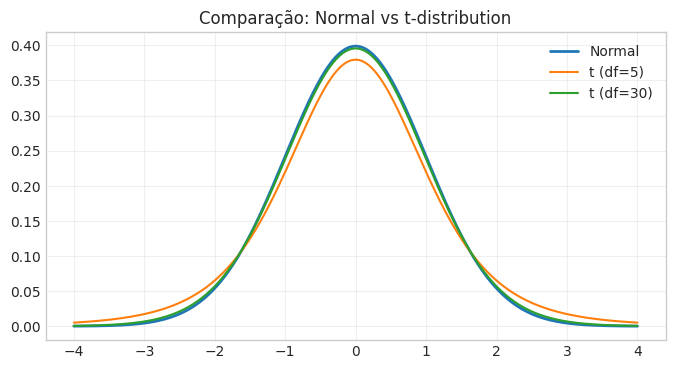

In [132]:
x = np.linspace(-4, 4, 400)

plt.figure(figsize=(8, 4))
plt.plot(x, norm.pdf(x), label="Normal", linewidth=2)
plt.plot(x, t.pdf(x, df=5), label="t (df=5)")
plt.plot(x, t.pdf(x, df=30), label="t (df=30)")
plt.title("Comparação: Normal vs t-distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

🟣 **Interpretação**

- df pequeno → caudas mais pesadas  
- df grande → aproxima a normal  

<br>

---

<a id="ab"></a>
[↑ Índice](#indice)
# 10. Teste A/B — Aplicação Moderna do Teste T

🔵 Conexão com o módulo 5 (IBM)  

O teste A/B nada mais é do que um **teste t de duas amostras independentes**, aplicado a um experimento com duas versões:

- A = controle  
- B = tratamento  

O módulo 5 ensina exatamente as ferramentas necessárias para conduzir um teste A/B:
- comparação de médias,
- teste t,
- valor‑p,
- variâncias iguais vs desiguais.

## 10.1 O que é um teste A/B?

Um teste A/B responde:

> A versão B produz um resultado diferente da versão A?

Exemplos típicos:
- página antiga x página nova  
- botão azul x botão vermelho  
- e‑mail curto x e‑mail longo  
- preço atual x preço novo  

> **Matematicamente, é um $teste \ t$ de duas amostras independentes.**

## 10.2 Estrutura estatística do teste A/B

| Estrutura | Estatística |
|-|-|
| Hipóteses gerais: | $ \to \qquad H_0: \mu_A = \mu_B $ <br> $ \to \qquad H_a: \mu_A \ne \mu_B $ |
| Ou, em testes unilaterais: | $ \to \qquad H_a: \mu_B > \mu_A $ <br> $ \to \qquad H_a: \mu_B < \mu_A $

O teste usa:

- t‑test com variâncias iguais (pooled), ou  
- t‑test de Welch (variâncias desiguais, mais robusto)

## 10.3 Exemplo prático com teachingratings

Vamos usar:

- A = turmas pequenas (≤ 40 alunos)  
- B = turmas grandes (> 40 alunos)  

Pergunta:

> Professores com mais alunos recebem notas diferentes?

In [133]:
### Criando os grupos

ratings_df["class_size"] = np.where(ratings_df["students"] <= 40, "A_small", "B_large")

A = ratings_df[ratings_df["class_size"] == "A_small"]["eval"]
B = ratings_df[ratings_df["class_size"] == "B_large"]["eval"]

### Teste A/B (Welch)

from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(A, B, equal_var=False)
t_stat, p_value

(np.float64(0.6711398017661315), np.float64(0.5027898436778071))

# 10.4 Interpretação do teste A/B

Regra geral:

- $p < 0.05 →$ rejeitamos $H₀ → A \ e \ B$ são diferentes  
- $p ≥ 0.05 →$ não rejeitamos $H₀ → A \ e \ B$ são estatisticamente iguais  

Interpretação prática:

- Se $p < 0.05:$ a mudança $(B)$ teve efeito real.  
- Se $p ≥ 0.05:$ a diferença pode ser apenas acaso.

No experimento A/B aplicado ao dataset *teachingratings*:

- estatística $t ≈ 0.671$  
- $p ≈ 0.503$  

**Como $p ≥ 0.05$:**

- **não rejeitamos $H₀$**  
- **não há evidência estatística de diferença entre A_small e B_large**  
- a diferença observada entre as médias é compatível com variação aleatória  
- **tamanho da turma não afeta a avaliação dos professores**

Conclusão prática:

A versão B (turmas grandes) não apresenta desempenho diferente da versão A (turmas pequenas).  
O experimento não fornece evidência de que o número de alunos influencie a nota média de avaliação.

## 10.5 Visualização do teste A/B

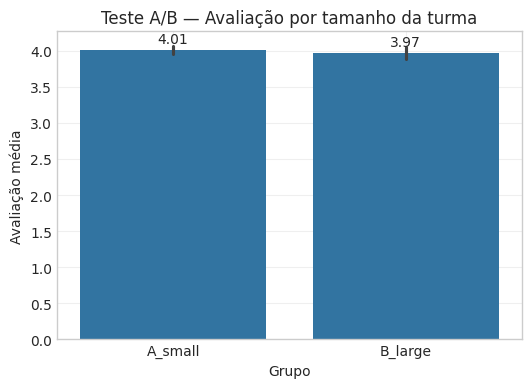

In [158]:
plt.figure(figsize=(6,4))

# Gráfico com IC usando a nova sintaxe
ax = sns.barplot(data=ratings_df, x="class_size", y="eval", errorbar=("ci", 95))

# Adicionando os números acima das barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Teste A/B — Avaliação por tamanho da turma")
plt.xlabel("Grupo"); plt.ylabel("Avaliação média"); plt.grid(alpha=0.3)
plt.show()


## 10.6 Conclusão

O teste A/B é simplesmente o teste t do módulo 5 aplicado a um experimento real.

Ele permite comparar duas versões (A e B) e decidir, com base em estatística, se a diferença observada é real ou apenas variação aleatória.

<br>

---

<br>

<a id="posts"></a>
[↑ Índice](#indice)
# 11. Posts


[↑ Teste ab](#ab)
## Teste A/B

Teste A/B 💡

O gráfico abaixo mostra dois jeitos de enxergar um teste A/B quando a diferença entre os grupos é pequena e estatisticamente fraca.

▪️ À esquerda: a distribuição t, que representa o comportamento estatístico da diferença entre os grupos.  
▪️ À direita: as médias observadas de A e B, com seus intervalos de confiança.  

1. As barras mostram a diferença observada
→ Grupo A: 4.01   
→ Grupo B: 3.97  
▪️ A diferença existe… mas é pequena. E só olhar para as barras não basta para concluir se ela é real ou apenas acaso.  

2. A curva t mostra o que a estatística enxerga  
→ A curva em sino representa todas as diferenças possíveis se A e B fossem realmente iguais.  
→ A linha pontilhada marca o valor encontrado no teste: t observado = 0.67  
→ O ponto vermelho mostra a densidade naquele valor.   
▪️ Ele cai bem no “miolo” da curva, em uma região comum, nada extrema. Ou seja: nada indica que a diferença observada seja especial.  

3. A área colorida indica o que seria considerado “diferença real”  
→ Quanto mais nas extremidades, mais improvável seria observar aquele valor se A e B fossem iguais.  
→ Como o nosso t está longe dessas regiões, a conclusão é direta:  
▪️ Não há evidência estatística de diferença entre A e B.  

A regra geral do teste A/B  
▪️ p < 0.05 → rejeita H₀ → A e B são diferentes  
▪️ p ≥ 0.05 → não rejeita H₀ → A e B são iguais  

No nosso caso:  
→ p ≈ 0.50    
→ Diferença totalmente compatível com o acaso.  

📈 A interpretação é simples  
→ Barras diferentes não significam diferença real  
→ O teste t mostra se a diferença é estatisticamente significativa  
→ Aqui, não é

🔣 Estatística: Uma forma de separar o que parece diferente do que realmente é diferente, com rigor, clareza e confiança.

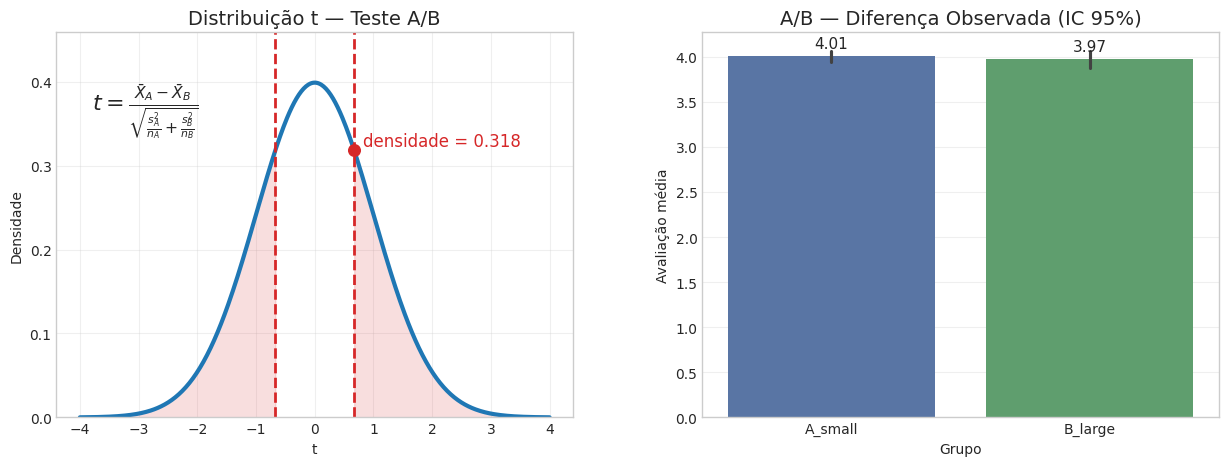

In [163]:
# --- Dados ---
A = ratings_df[ratings_df["class_size"] == "A_small"]["eval"]
B = ratings_df[ratings_df["class_size"] == "B_large"]["eval"]
t_obs = 0.671
df = len(A) + len(B) - 2

# curva t
x = np.linspace(-4, 4, 400)
y = t.pdf(x, df)
y_obs = t.pdf(t_obs, df)

# --- Figura com dois gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) GRÁFICO ESQUERDO — DISTRIBUIÇÃO t
axes[0].plot(x, y, color="#1f77b4", linewidth=3)
axes[0].axvline(t_obs, color="#d62728", linestyle="--", linewidth=2)
axes[0].axvline(-t_obs, color="#d62728", linestyle="--", linewidth=2)
axes[0].scatter([t_obs], [y_obs], color="#d62728", s=70, zorder=5)

axes[0].text(t_obs + 0.15, y_obs, f"densidade = {y_obs:.3f}", fontsize=12, color="#d62728", verticalalignment="bottom")
axes[0].fill_between(x, y, where=(x > abs(t_obs)), color="#d62728", alpha=0.15)
axes[0].fill_between(x, y, where=(x < -abs(t_obs)), color="#d62728", alpha=0.15)
axes[0].text(
    -3.8, max(y)*0.92,
    r"$t = \frac{\bar{X}_A - \bar{X}_B}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}}$",
    fontsize=16
)
axes[0].set_title("Distribuição t — Teste A/B", fontsize=14)
axes[0].set_xlabel("t"); axes[0].set_ylabel("Densidade"); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, max(y)*1.15)

# 2) GRÁFICO DIREITO — BARPLOT A/B COM INTERPRETAÇÃO
sns.barplot(data=ratings_df, x="class_size", y="eval", hue="class_size", legend=False, errorbar=("ci", 95), palette=["#4C72B0", "#55A868"], ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=4, fontsize=11)
axes[1].set_title("A/B — Diferença Observada (IC 95%)", fontsize=14)
axes[1].set_xlabel("Grupo"); axes[1].set_ylabel("Avaliação média"); axes[1].grid(axis="y", alpha=0.3)

# Ajuste de espaçamento (substitui tight_layout)
plt.subplots_adjust(wspace=0.25)

plt.show()


[↑ Anova](#anova)
## ANOVA

ANOVA — quando a diferença entre grupos é real  
O teste ANOVA ajuda a responder uma pergunta essencial:  

👉 “Essas diferenças entre grupos são reais ou apenas ruído?”  

Aqui, aplicamos o ANOVA à variável beauty, que mede aparência física, comparando três faixas etárias.  

▪️ O que o gráfico mostra  
1. Distribuições KDE   
As curvas revelam separação clara: os mais jovens tendem a ter valores de beauty maiores, e os mais velhos, menores.  
Visualmente, já há indício de diferença real.  

2. F‑score e p‑value   
O ANOVA compara a variabilidade entre grupos com a variabilidade dentro dos grupos.  
O F elevado e o p < 0.001 indicam que as médias diferem de forma significativa — a diferença não é acaso.  

3. Boxplot  
A mediana de beauty diminui com a idade, confirmando o padrão observado nas curvas.  
O gráfico reforça o resultado estatístico.

▪️ Conclusão  
Idade altera beauty.  
O grupo ≤40 tende a ter valores mais altos, enquanto o grupo ≥57 apresenta valores menores.  
A aparência varia com a idade — o que é coerente, já que a variável mede traços físicos.  

📈 A interpretação é simples   
→ Diferenças visuais nem sempre significam diferença real.  
→ O ANOVA mostra quando elas são estatisticamente sustentadas.  
→ Aqui, são.

🔣 Estatística: uma forma de transformar variações aparentes em conclusões sólidas — com rigor, clareza e confiança.

/tmp/ipykernel_10727/730680485.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=teacher, x="age_group", y="beauty", # hue="age_group",


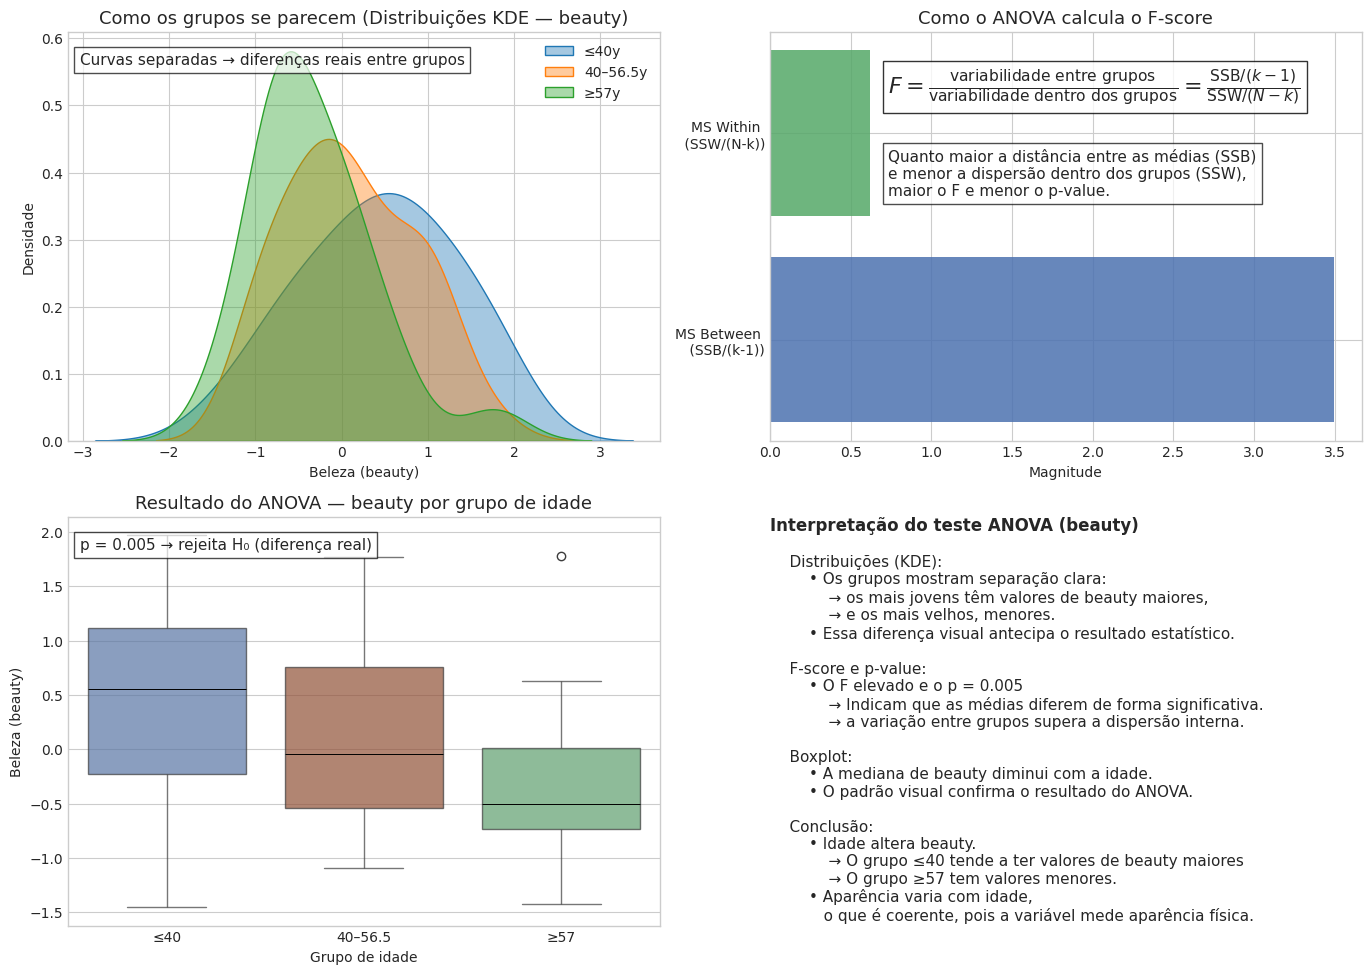

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

plt.style.use("seaborn-v0_8-whitegrid")

# -----------------------------
# Dados
# -----------------------------
ratings_df = pd.read_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv")
teacher = ratings_df.groupby("prof").agg({"gender": "first", "tenure": "first", "age": "first", "beauty": "mean"})


# Criar grupos de idade (mesmo do NB5)
bins = [0, 40, 56.5, 100]
labels = ["≤40", "40–56.5", "≥57"]
teacher["age_group"] = pd.cut(teacher["age"], bins=bins, labels=labels, include_lowest=True)

# Grupos
g1 = teacher[teacher["age_group"] == "≤40"]["beauty"]
g2 = teacher[teacher["age_group"] == "40–56.5"]["beauty"]
g3 = teacher[teacher["age_group"] == "≥57"]["beauty"]

# ANOVA
F_stat, p_value = f_oneway(g1, g2, g3)

# Figura 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================
# QUADRANTE 1 — Distribuições KDE (beauty)
# ============================================================
ax1 = axes[0, 0]

sns.kdeplot(g1, fill=True, alpha=0.4, label="≤40y", ax=ax1)
sns.kdeplot(g2, fill=True, alpha=0.4, label="40–56.5y", ax=ax1)
sns.kdeplot(g3, fill=True, alpha=0.4, label="≥57y", ax=ax1)

ax1.set_title("Como os grupos se parecem (Distribuições KDE — beauty)", fontsize=13)
ax1.set_xlabel("Beleza (beauty)"); ax1.set_ylabel("Densidade"); ax1.legend()

ax1.text(0.02, 0.92,
    "Curvas separadas → diferenças reais entre grupos",
    transform=ax1.transAxes, fontsize=11, bbox=dict(facecolor="white", alpha=0.7))

# ============================================================
# NOVO QUADRANTE 2 — F-score com fórmula integrada
# ============================================================
ax2 = axes[0, 1]

k = 3  # número de grupos
N = len(teacher)

# Cálculo dos termos da fórmula
overall_mean = teacher["beauty"].mean()

ss_between = sum([
    len(g1) * (g1.mean() - overall_mean)**2,
    len(g2) * (g2.mean() - overall_mean)**2,
    len(g3) * (g3.mean() - overall_mean)**2
])

ss_within = sum([
    sum((g1 - g1.mean())**2),
    sum((g2 - g2.mean())**2),
    sum((g3 - g3.mean())**2)
])

ms_between = ss_between / (k - 1)
ms_within  = ss_within  / (N - k)

ax2.barh(["MS Between \n (SSB/(k-1))", "MS Within \n (SSW/(N-k))"],
         [ms_between, ms_within], color=["#4C72B0", "#55A868"], alpha=0.85)

ax2.set_title("Como o ANOVA calcula o F‑score", fontsize=13)
ax2.set_xlabel("Magnitude")

# Fórmula dentro do gráfico
ax2.text(0.2, 0.85,
    r"$F = \frac{\text{variabilidade entre grupos}} {\text{variabilidade dentro dos grupos}} = \frac{\text{SSB}/(k-1)}{\text{SSW}/(N-k)}$",
    transform=ax2.transAxes, fontsize=16, bbox=dict(facecolor="white", alpha=0.8))

# Interpretação visual
ax2.text(    0.2, 0.60,
    "Quanto maior a distância entre as médias (SSB)\n"
    "e menor a dispersão dentro dos grupos (SSW),\n"
    "maior o F e menor o p‑value.",
    transform=ax2.transAxes, fontsize=11, bbox=dict(facecolor="white", alpha=0.7))

# ============================================================
# QUADRANTE 3 — Boxplot de beauty com p‑value
# ============================================================
ax3 = axes[1, 0]

sns.boxplot(data=teacher, x="age_group", y="beauty", # hue="age_group",
            palette=["#4C72B0", "#A04A28", "#55A868"], ax=ax3,
            boxprops=dict(alpha=0.7), whiskerprops=dict(alpha=0.7), capprops=dict(alpha=0.7), medianprops=dict(color="black", linewidth=0.7))

ax3.set_title("Resultado do ANOVA — beauty por grupo de idade", fontsize=13)
ax3.set_xlabel("Grupo de idade"); ax3.set_ylabel("Beleza (beauty)")

# p-value científico
p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"

ax3.text(0.02, 0.92,
    f"{p_text} → rejeita H₀ (diferença real)",
    transform=ax3.transAxes, fontsize=11, bbox=dict(facecolor="white", alpha=0.7))

# ============================================================
# QUADRANTE 4 — Painel didático
# ============================================================
ax4 = axes[1, 1]
ax4.axis("off")

ax4.text(0, 1,
    "Interpretação do teste ANOVA (beauty)\n",
    fontsize=12, fontweight="bold", va="top")

texto = (
    "\n    Distribuições (KDE):\n"
    "        • Os grupos mostram separação clara:\n"
    "            → os mais jovens têm valores de beauty maiores,\n"
    "            → e os mais velhos, menores.\n"
    "        • Essa diferença visual antecipa o resultado estatístico.\n\n"
    
    "    F‑score e p‑value:\n"
    f"        • O F elevado e o {p_text}\n" 
    "            → Indicam que as médias diferem de forma significativa.\n"
    "            → a variação entre grupos supera a dispersão interna.\n\n"
    
    "    Boxplot:\n"
    "        • A mediana de beauty diminui com a idade.\n"
    "        • O padrão visual confirma o resultado do ANOVA.\n\n"
    
    "    Conclusão:\n"
    "        • Idade altera beauty.\n"
    "            → O grupo ≤40 tende a ter valores de beauty maiores\n"
    "            → O grupo ≥57 tem valores menores.\n"
    "        • Aparência varia com idade,\n" 
    "           o que é coerente, pois a variável mede aparência física."
)

ax4.text(0, 0.95, texto, fontsize=11, va="top")

plt.tight_layout()
plt.show()

In [29]:
F_manual = ms_between / ms_within
print(F_manual, F_stat)


5.606742142628374 5.606742142628375


In [129]:
import numpy as np
from scipy.stats import ttest_ind

# Amostras
amostra1 = np.array([9, 11, 10, 11, 10, 12, 9, 11, 12, 9, 10])
amostra2 = np.array([10, 13, 10, 13, 12, 9, 11, 12, 12, 12, 12, 13])

# Teste t de duas amostras independentes, variâncias iguais
t_stat, p_val = ttest_ind(amostra1, amostra2, equal_var=True)

print("Estatística t:", t_stat)
print("p-valor:", p_val)


Estatística t: -2.387210081259794
p-valor: 0.026458412637470497


In [130]:
# Dados
mu = 63.18
sigma = 13.27
x = 91.54

# Cálculo do z-score
z = (x - mu) / sigma
print(f"z-score = {z:.3f}")


z-score = 2.137


In [132]:
import math
from scipy.stats import norm

mu0 = 400
xbar = 414
sigma = 22
n = 10

z = (xbar - mu0) / (sigma / math.sqrt(n))
print(f"z-score = {z:.3f}")

p_value = 1 - norm.cdf(z)
print(f"p-valor = {p_value:.4f}")

z-score = 2.012
p-valor = 0.0221


In [133]:
from scipy.stats import norm

mu = 490
sigma = 20
x = 500

# Probabilidade de X >= 500
p = 1 - norm.cdf(x, loc=mu, scale=sigma)
print(f"Probabilidade = {p:.4f}")

Probabilidade = 0.3085


In [134]:
import numpy as np

mu = 90
sigma = 20
dados = np.array([73.8, 88.0, 81.2, 76.6])

z = (dados - mu) / sigma
print(np.round(z, 3))

[-0.81 -0.1  -0.44 -0.67]
